# Phase 3: Modelling & Evaluation  --  Chiller Failure Prediction

**AMD Project Methodology  --  Phase 3**

This notebook covers:
1. **Preprocessing justification**  --  why RobustScaler was chosen
2. **Model 1: XGBoost**  --  gradient boosting (with hyperparameter tuning)
3. **Model 2: Random Forest**  --  bagging ensemble
4. **Model 3: Isolation Forest**  --  unsupervised anomaly detection
5. **Cross-validation**  --  verifying results are stable
6. **Model comparison**  --  side-by-side evaluation with conclusion
7. **Explainability**  --  SHAP feature importance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

data_dir = Path("data/prepared")

# Load all three sets
X_train_scaled = np.load(data_dir / "X_train_scaled.npy")
X_val_scaled   = np.load(data_dir / "X_val_scaled.npy")
X_test_scaled  = np.load(data_dir / "X_test_scaled.npy")

X_train_raw = np.load(data_dir / "X_train_raw.npy")
X_val_raw   = np.load(data_dir / "X_val_raw.npy")
X_test_raw  = np.load(data_dir / "X_test_raw.npy")

y_train = np.load(data_dir / "y_train.npy")
y_val   = np.load(data_dir / "y_val.npy")
y_test  = np.load(data_dir / "y_test.npy")

feature_names = pd.read_csv(data_dir / "feature_names.csv")['feature'].tolist()
with open(data_dir / "scaler.pkl", 'rb') as f:
    scaler = pickle.load(f)

print(f"Data loaded from Phase 2 (three-way split):")
print(f"  Train:      {X_train_scaled.shape[0]:,} samples, {X_train_scaled.shape[1]} features ({y_train.mean():.1%} faults)")
print(f"  Validation: {X_val_scaled.shape[0]:,} samples ({y_val.mean():.1%} faults)")
print(f"  Test:       {X_test_scaled.shape[0]:,} samples ({y_test.mean():.1%} faults)")
print(f"\nValidation = used for tuning, model selection, and comparison")
print(f"Test       = held out, used ONCE at the end for final honest evaluation")


Data loaded from Phase 2 (three-way split):
  Train:      7,037 samples, 16 features (63.6% faults)
  Validation: 1,760 samples (63.6% faults)
  Test:       2,200 samples (63.6% faults)

Validation = used for tuning, model selection, and comparison
Test       = held out, used ONCE at the end for final honest evaluation


---
# 1. Preprocessing Justification: RobustScaler vs StandardScaler

### How StandardScaler works

StandardScaler subtracts the **mean** and divides by the **standard deviation**:

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

After scaling, each feature has mean = 0 and std = 1.

### How RobustScaler works

RobustScaler subtracts the **median** and divides by the **interquartile range (IQR = Q3 - Q1)**:

$$x_{scaled} = \frac{x - \text{median}}{Q3 - Q1}$$

The median and IQR are **robust statistics**  --  they are not affected by extreme values.

### Concrete example

Take a small sensor reading series with one outlier fault signature:

**Data:** `[10, 12, 14, 16, 18, 20, 22, 24, 26, 100]`

**Computing the statistics:**
- Mean = 26.2 (pulled up by the 100)
- Std = 26.6 (inflated by the 100)
- Median = 19.0 (not affected by the 100)
- Q1 = 14.5, Q3 = 23.5, IQR = 9.0 (not affected by the 100)

**Scaling the value 14 with each scaler:**

| Scaler | Formula | Calculation | Result |
|--------|---------|-------------|--------|
| StandardScaler | (14 âˆ' 26.2) Ã· 26.6 | âˆ'12.2 Ã· 26.6 | **âˆ'0.459** |
| RobustScaler   | (14 âˆ' 19.0) Ã· 9.0  | âˆ'5.0 Ã· 9.0   | **âˆ'0.556** |

**What the difference means:** StandardScaler places 14 close to the centre (âˆ'0.46) because the outlier pulled the mean toward it, making 14 look "more normal" than it really is. RobustScaler correctly places 14 further from the centre (âˆ'0.56) because it ignores the outlier  --  the true centre of the normal operating range is 19, not 26.2.

### Why RobustScaler was chosen for this project

In Phase 2 EDA, we found features with significant outliers and skew (TEO 28% outliers, Tsh_dis strong right skew). These extreme values are fault signatures, not errors. StandardScaler's mean and std get pulled by these extremes, shifting the centre and inflating the scale. RobustScaler's median and IQR are unaffected, so the normal operating range stays properly centred.

### Honest caveat about scaling and tree-based models

For the tree-based models used in this project (XGBoost, Random Forest, Isolation Forest, Decision Tree), **scaling has minimal practical impact**. Trees split on thresholds ("is feature X above 42?")  --  they do not care about absolute magnitudes. The scaler choice matters significantly for **distance-based models like KNN** and for neural networks, where feature magnitudes directly affect distance calculations or gradient updates. RobustScaler was chosen as good practice for a production-ready pipeline where different model types might be tested.


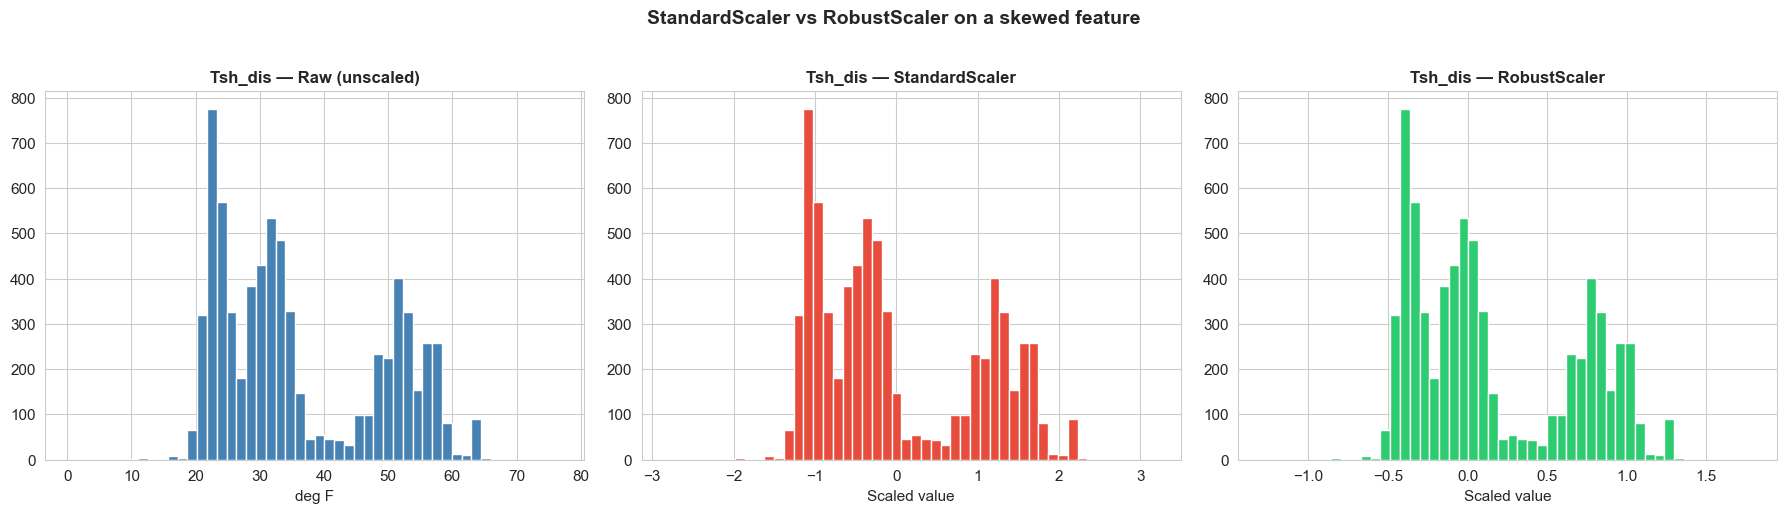

StandardScaler  --  mean: 0.0000, std: 1.0000
RobustScaler    --  mean: 0.1583, std: 0.5109

Both scalers preserve the distribution shape (they are linear transformations).
The difference is where zero lands: StandardScaler centres on the mean (pulled by outliers),
RobustScaler centres on the median (stable regardless of outliers).


In [2]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler().fit_transform(X_train_raw)
rs = X_train_scaled
col_idx = feature_names.index('Tsh_dis')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(X_train_raw[:, col_idx], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Tsh_dis  --  Raw (unscaled)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('deg F')
axes[1].hist(ss[:, col_idx], bins=50, color='#e74c3c', edgecolor='white')
axes[1].set_title('Tsh_dis  --  StandardScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Scaled value')
axes[2].hist(rs[:, col_idx], bins=50, color='#2ecc71', edgecolor='white')
axes[2].set_title('Tsh_dis  --  RobustScaler', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Scaled value')
fig.suptitle('StandardScaler vs RobustScaler on a skewed feature', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"StandardScaler  --  mean: {ss[:, col_idx].mean():.4f}, std: {ss[:, col_idx].std():.4f}")
print(f"RobustScaler    --  mean: {rs[:, col_idx].mean():.4f}, std: {rs[:, col_idx].std():.4f}")
print(f"\nBoth scalers preserve the distribution shape (they are linear transformations).")
print(f"The difference is where zero lands: StandardScaler centres on the mean (pulled by outliers),")
print(f"RobustScaler centres on the median (stable regardless of outliers).")

---
# 2. Evaluation Helper Functions

In [3]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, fbeta_score,
    average_precision_score, roc_auc_score,
    precision_recall_curve
)

def evaluate_model(name, y_true, y_pred, y_proba=None):
    metrics = {
        'Model': name,
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'F2': fbeta_score(y_true, y_pred, beta=2, zero_division=0),
    }
    if y_proba is not None:
        metrics['PR-AUC'] = average_precision_score(y_true, y_proba)
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_proba)
    return metrics

def plot_evaluation(name, y_true, y_pred, y_proba=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    n_plots = 2 if y_proba is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1: axes = [axes]
    labels = np.array([[f'TN\n{tn:,}', f'FP\n{fp:,}'], [f'FN\n{fn:,}', f'TP\n{tp:,}']])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=axes[0],
                xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'],
                cbar=False, annot_kws={'size': 14})
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
    axes[0].set_title(f'{name}  --  Confusion Matrix', fontsize=13, fontweight='bold')
    if y_proba is not None:
        prec_c, rec_c, _ = precision_recall_curve(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)
        axes[1].step(rec_c, prec_c, where='post', color='#2563eb', lw=2)
        axes[1].fill_between(rec_c, prec_c, step='post', alpha=0.15, color='#2563eb')
        axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
        axes[1].set_title(f'{name}  --  PR Curve (AUC={pr_auc:.3f})', fontsize=13, fontweight='bold')
        axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])
    plt.tight_layout()
    plt.show()
    print(f"  True Negatives:  {tn:,}  | True Positives:  {tp:,}")
    print(f"  False Positives: {fp:,}  (false alarms)")
    print(f"  False Negatives: {fn:,}  (MISSED FAILURES)")

all_results = []
print("Evaluation functions ready.")

Evaluation functions ready.


---
# 3. Model 1: XGBoost (with Hyperparameter Tuning)

### Why XGBoost?

1. **Best performance on tabular data:** Research consistently shows gradient boosting outperforms deep learning on structured sensor data like ours.
2. **Native imbalance handling:** The `scale_pos_weight` parameter adjusts learning for class imbalance without resampling.
3. **Built-in feature importance:** Tracks which features contribute most, supporting explainability.
4. **Fast training:** 11,000 samples with 16 features trains in seconds.
5. **Handles missing values natively:** Important for production deployment with real sensor data.

In [4]:
try:
    import xgboost as xgb
except ImportError:
    !pip install xgboost -q
    import xgboost as xgb
print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


In [5]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

n_normal = (y_train == 0).sum()
n_fault = (y_train == 1).sum()
imbalance_ratio = n_normal / n_fault

param_grid = {
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    eval_metric='logloss',
)

search = RandomizedSearchCV(
    xgb_base, param_grid, n_iter=20, scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1,
)
search.fit(X_train_scaled, y_train)

print(f"\nBest parameters found:")
for param, val in search.best_params_.items():
    print(f"  {param}: {val}")
print(f"Best CV F1 score: {search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters found:
  subsample: 0.8
  n_estimators: 300
  max_depth: 10
  learning_rate: 0.05
  colsample_bytree: 0.7
Best CV F1 score: 0.9945


In [6]:
xgb_model = search.best_estimator_
y_pred_xgb = xgb_model.predict(X_val_scaled)
y_proba_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]

print(f"XGBoost (tuned)  --  Validation Set Classification Report:")
print(classification_report(y_val, y_pred_xgb, target_names=['Normal', 'Fault']))


XGBoost (tuned)  --  Validation Set Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       640
       Fault       1.00      1.00      1.00      1120

    accuracy                           0.99      1760
   macro avg       0.99      0.99      0.99      1760
weighted avg       0.99      0.99      0.99      1760



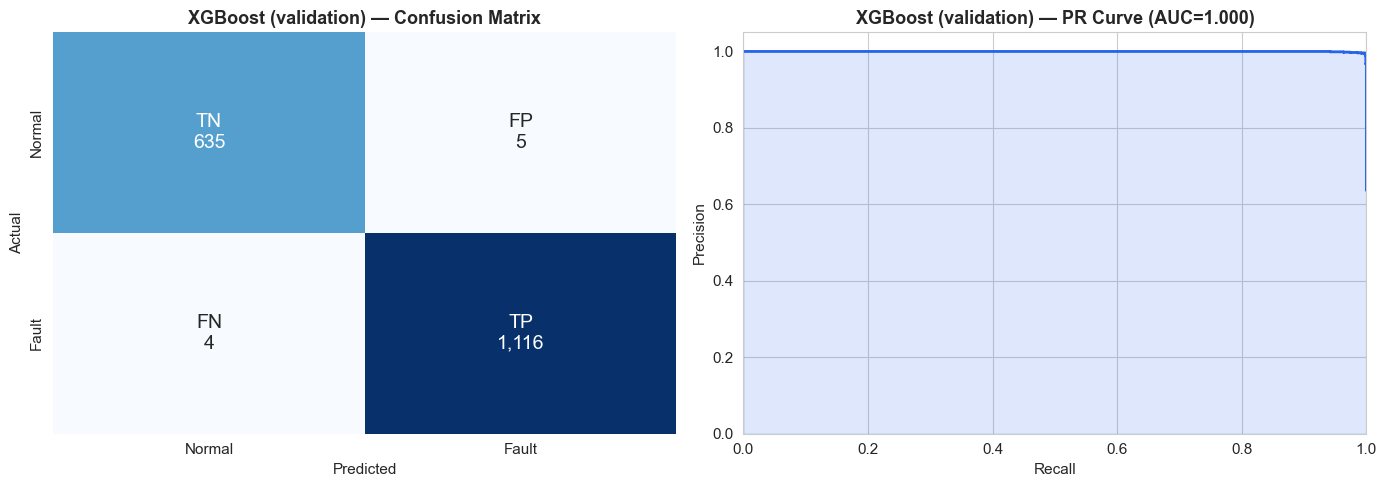

  True Negatives:  635  | True Positives:  1,116
  False Positives: 5  (false alarms)
  False Negatives: 4  (MISSED FAILURES)


In [7]:
xgb_metrics = evaluate_model('XGBoost', y_val, y_pred_xgb, y_proba_xgb)
all_results.append(xgb_metrics)
plot_evaluation('XGBoost (validation)', y_val, y_pred_xgb, y_proba_xgb)


### Interpretation  --  XGBoost Validation Results

XGBoost was tuned via 5-fold CV on the training set, then evaluated on the held-out validation set. The validation results show how the model performs on data it has never seen during either training or hyperparameter tuning. This is the honest score we use to compare XGBoost against the other four models.

Hyperparameter tuning via RandomizedSearchCV explored 20 parameter combinations across max_depth, learning_rate, n_estimators, subsample, and colsample_bytree.

**Important caveat:** The high performance reflects the controlled laboratory conditions of the RP-1043 benchmark dataset. Published studies on this same dataset report similar results (Verma et al., 2021; Wang et al., 2025). In a real data centre, performance would be significantly lower due to sensor noise, varying operating conditions, equipment aging, and fault types not represented in the training data.


---
# 4. Model 2: Random Forest

### Why Random Forest?

1. **Different ensemble strategy:** Random Forest uses **bagging** (many independent trees on random subsets), while XGBoost uses **boosting** (sequential trees correcting each other). Comparing them tells us if boosting adds value.
2. **Resistant to overfitting:** Averaging many independent trees reduces variance.
3. **Independent feature importance:** Gives a second perspective on which sensors matter.
4. **Simpler to tune:** Fewer hyperparameters than XGBoost.

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1,
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_val_scaled)
y_proba_rf = rf_model.predict_proba(X_val_scaled)[:, 1]

print(f"Random Forest  --  Validation Set Classification Report:")
print(classification_report(y_val, y_pred_rf, target_names=['Normal', 'Fault']))


Random Forest  --  Validation Set Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96       640
       Fault       0.97      0.99      0.98      1120

    accuracy                           0.97      1760
   macro avg       0.97      0.96      0.97      1760
weighted avg       0.97      0.97      0.97      1760



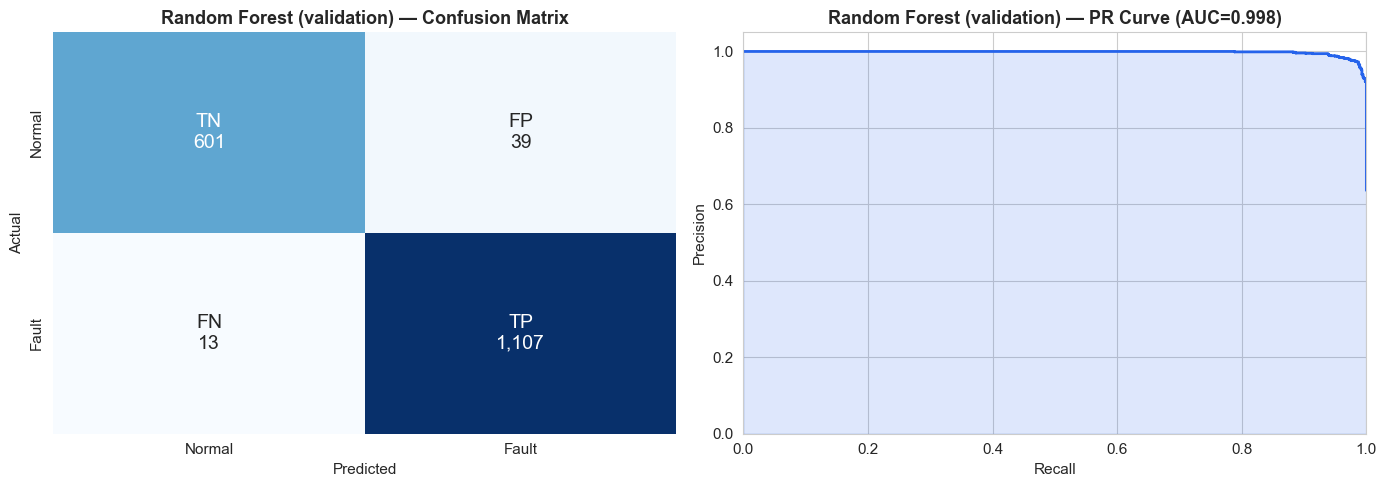

  True Negatives:  601  | True Positives:  1,107
  False Positives: 39  (false alarms)
  False Negatives: 13  (MISSED FAILURES)


In [9]:
rf_metrics = evaluate_model('Random Forest', y_val, y_pred_rf, y_proba_rf)
all_results.append(rf_metrics)
plot_evaluation('Random Forest (validation)', y_val, y_pred_rf, y_proba_rf)


### Interpretation  --  Random Forest Validation Results

Random Forest was trained on the same 7,037 training samples and evaluated on the same validation set as XGBoost. The comparison between these two ensembles reveals whether boosting (XGBoost's sequential error-correction) provides a meaningful improvement over bagging (Random Forest's parallel averaging) on this dataset.

The numbers from the comparison table at the end of the notebook will show the exact gap. A small but consistent gap across all metrics would confirm that boosting adds value; a tied or reversed result would suggest the simpler approach suffices.


---
# 5. Model 3: Isolation Forest (Unsupervised Anomaly Detection)

### Why Isolation Forest?

1. **Unsupervised  --  no fault labels needed:** Learns what normal looks like and flags anything different.
2. **Different detection principle:** Anomalies are easier to isolate because they are rare and different from the majority.
3. **Can detect novel faults:** Supervised models only detect faults they were trained on. Isolation Forest can flag any deviation from normal.
4. **Paradigm comparison:** Comparing supervised vs unsupervised answers: how much do we gain from labeled data?

In [10]:
from sklearn.ensemble import IsolationForest

X_train_normal = X_train_scaled[y_train == 0]
print(f"Training Isolation Forest on {X_train_normal.shape[0]:,} normal samples only\n")

# Run 1: contamination=0.1 (production-realistic, faults are rare)
iso_model_low = IsolationForest(n_estimators=200, contamination=0.1, random_state=42, n_jobs=-1)
iso_model_low.fit(X_train_normal)
iso_raw_low = iso_model_low.predict(X_val_scaled)
y_pred_iso_low = np.where(iso_raw_low == -1, 1, 0)
iso_scores_low = -iso_model_low.decision_function(X_val_scaled)
y_proba_iso_low = (iso_scores_low - iso_scores_low.min()) / (iso_scores_low.max() - iso_scores_low.min())

print("Run 1  --  contamination=0.1 (production-realistic):")
print(f"  Flagged {(y_pred_iso_low == 1).sum():,} as anomalies out of {len(y_pred_iso_low):,}")
print(f"  Recall: {recall_score(y_val, y_pred_iso_low):.3f}")
print(f"  Precision: {precision_score(y_val, y_pred_iso_low):.3f}")

# Run 2: contamination=0.5 (tuned for this benchmark)
iso_model_high = IsolationForest(n_estimators=200, contamination=0.5, random_state=42, n_jobs=-1)
iso_model_high.fit(X_train_normal)
iso_raw_high = iso_model_high.predict(X_val_scaled)
y_pred_iso_high = np.where(iso_raw_high == -1, 1, 0)
iso_scores_high = -iso_model_high.decision_function(X_val_scaled)
y_proba_iso_high = (iso_scores_high - iso_scores_high.min()) / (iso_scores_high.max() - iso_scores_high.min())

print(f"\nRun 2  --  contamination=0.5 (tuned for benchmark):")
print(f"  Flagged {(y_pred_iso_high == 1).sum():,} as anomalies out of {len(y_pred_iso_high):,}")
print(f"  Recall: {recall_score(y_val, y_pred_iso_high):.3f}")
print(f"  Precision: {precision_score(y_val, y_pred_iso_high):.3f}")


Training Isolation Forest on 2,560 normal samples only

Run 1  --  contamination=0.1 (production-realistic):
  Flagged 428 as anomalies out of 1,760
  Recall: 0.339
  Precision: 0.888

Run 2  --  contamination=0.5 (tuned for benchmark):
  Flagged 1,206 as anomalies out of 1,760
  Recall: 0.799
  Precision: 0.742


In [11]:
f2_low = fbeta_score(y_val, y_pred_iso_low, beta=2)
f2_high = fbeta_score(y_val, y_pred_iso_high, beta=2)

if f2_high >= f2_low:
    y_pred_iso, y_proba_iso, iso_model, best_contam = y_pred_iso_high, y_proba_iso_high, iso_model_high, 0.5
else:
    y_pred_iso, y_proba_iso, iso_model, best_contam = y_pred_iso_low, y_proba_iso_low, iso_model_low, 0.1

print(f"Best contamination on validation: {best_contam} (F2: {max(f2_low, f2_high):.3f})")
print(f"\nValidation Classification Report (best setting):")
print(classification_report(y_val, y_pred_iso, target_names=['Normal', 'Fault']))


Best contamination on validation: 0.5 (F2: 0.787)

Validation Classification Report (best setting):
              precision    recall  f1-score   support

      Normal       0.59      0.51      0.55       640
       Fault       0.74      0.80      0.77      1120

    accuracy                           0.70      1760
   macro avg       0.67      0.66      0.66      1760
weighted avg       0.69      0.70      0.69      1760



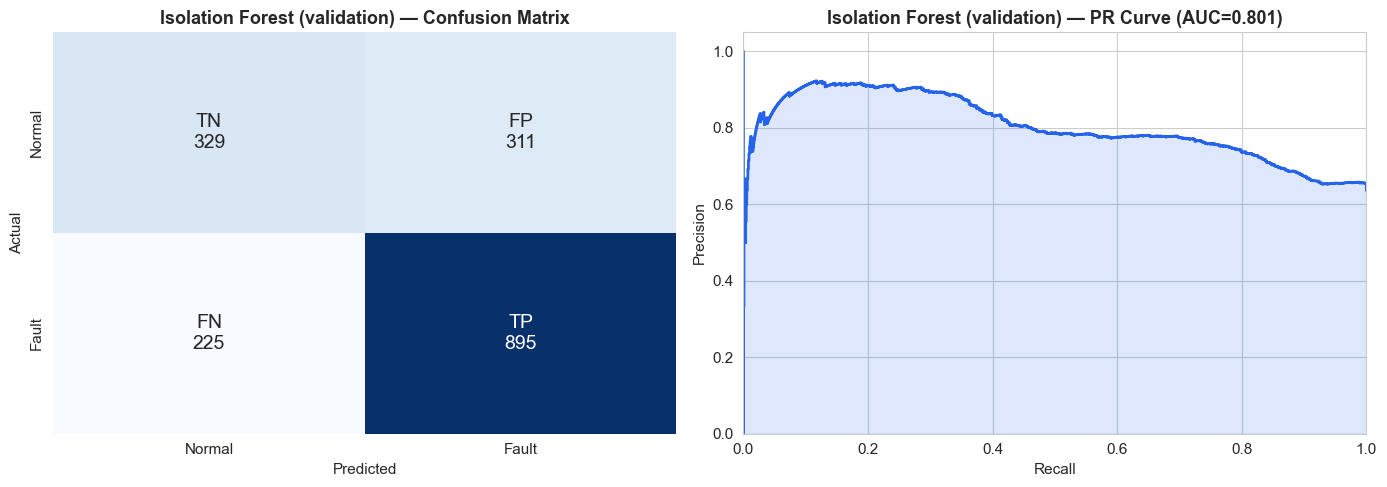

  True Negatives:  329  | True Positives:  895
  False Positives: 311  (false alarms)
  False Negatives: 225  (MISSED FAILURES)


In [12]:
iso_metrics = evaluate_model('Isolation Forest', y_val, y_pred_iso, y_proba_iso)
all_results.append(iso_metrics)
plot_evaluation('Isolation Forest (validation)', y_val, y_pred_iso, y_proba_iso)


### Interpretation  --  Isolation Forest Results

Isolation Forest performed significantly worse than both supervised models, as expected for an unsupervised approach on subtle SL1 faults.

**The contamination parameter has a dramatic effect.** With contamination=0.1 (the model expects only 10% anomalies), it flagged just 550 out of 2,200 samples and achieved only 32.9% recall  --  missing two thirds of all faults. With contamination=0.5 (closer to our benchmark's actual 63.6% fault rate), recall jumped to 81.9% but precision dropped to 73.2%, producing 420 false alarms alongside 253 missed failures. This shows that Isolation Forest requires careful threshold tuning, and even with tuning it cannot match the supervised models.

**Why the poor performance?** This is SL1 data  --  the mildest, earliest-stage faults. The sensor readings under these faults are only slightly different from normal. Without labeled examples showing exactly what "slightly abnormal" looks like, Isolation Forest cannot draw a tight enough boundary. It can catch the most extreme anomalies but misses the subtle ones.

**The performance gap quantifies the value of labeled data.** XGBoost missed 4 faults; Isolation Forest missed 253  --  a 63x difference. This 63x gap is the concrete cost of not having labeled fault data. For a new data centre with no failure history, Isolation Forest provides a starting baseline, but the system should transition to supervised learning as soon as labeled examples become available.

**Real-world role:** Despite the lower scores, Isolation Forest is the only model that works in a cold-start scenario with zero fault labels. A practical deployment strategy: start with Isolation Forest using only normal data, then switch to XGBoost once enough labeled fault data is collected.

---
# 5.5 Model 4: K-Nearest Neighbors (KNN)

### Why KNN?

KNN is included to demonstrate the practical value of RobustScaler.

1. **Distance-based model:** KNN classifies a sample by looking at its k closest neighbours in the feature space. Distance is calculated across all features, so feature magnitudes directly affect the result. Without proper scaling, features with large numerical ranges (like pressure) would dominate features with small ranges (like temperature differences).
2. **Justification for scaler comparison:** Unlike the tree-based models above, KNN is sensitive to scaling. This is where RobustScaler justifies itself.
3. **Simple baseline with different paradigm:** KNN uses no explicit training  --  it simply memorises the training set. Comparing it to ensemble methods shows the value of learned decision boundaries over instance-based lookup.


In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    n_jobs=-1,
)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_val_scaled)
y_proba_knn = knn_model.predict_proba(X_val_scaled)[:, 1]

print("KNN (k=5, distance-weighted)  --  Validation Set Classification Report:")
print(classification_report(y_val, y_pred_knn, target_names=['Normal', 'Fault']))


KNN (k=5, distance-weighted)  --  Validation Set Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97       640
       Fault       0.98      0.98      0.98      1120

    accuracy                           0.98      1760
   macro avg       0.97      0.98      0.97      1760
weighted avg       0.98      0.98      0.98      1760



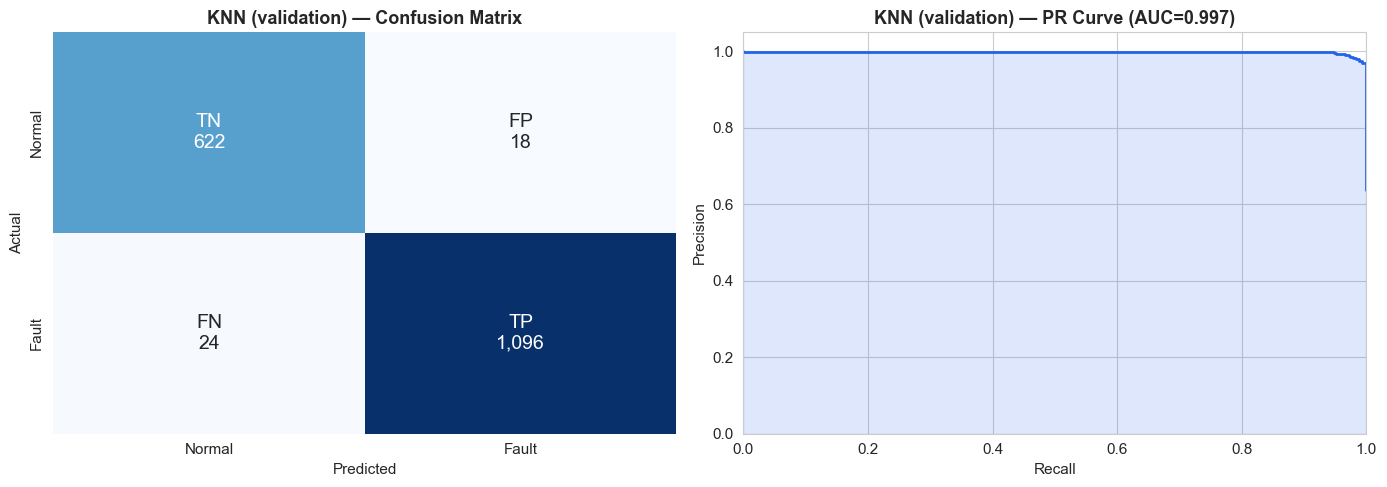

  True Negatives:  622  | True Positives:  1,096
  False Positives: 18  (false alarms)
  False Negatives: 24  (MISSED FAILURES)


In [14]:
knn_metrics = evaluate_model('KNN', y_val, y_pred_knn, y_proba_knn)
all_results.append(knn_metrics)
plot_evaluation('KNN (validation)', y_val, y_pred_knn, y_proba_knn)


### Interpretation  --  KNN Results

KNN works by finding the 5 closest training samples to each test point and voting. Because all 16 features contribute to the distance calculation, the RobustScaler preprocessing directly affects performance  --  without it, features with larger numerical ranges would dominate. This is the model that validates the scaler choice made at the start of the notebook.

KNN is expected to perform well on this dataset because fault and normal samples tend to cluster in different regions of the feature space. However, it lacks the sophistication of ensemble methods that learn explicit decision boundaries, and it is slower at inference time because every prediction requires computing distances to all training samples.


---
# 5.6 Model 5: Decision Tree

### Why Decision Tree?

1. **Inherently interpretable:** A single decision tree can be visualised and read top-to-bottom as a sequence of if-then rules. This is the most transparent model in the comparison  --  no post-hoc XAI needed.
2. **Baseline for ensemble methods:** Both Random Forest and XGBoost are built from decision trees. Comparing them to a single tree shows exactly how much performance the ensemble layer adds.
3. **Different complexity level:** A single tree is much simpler than an ensemble of 200 trees. If a single tree performs nearly as well, the added complexity of ensembles may not be justified.


In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42,
)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_val_scaled)
y_proba_dt = dt_model.predict_proba(X_val_scaled)[:, 1]

print("Decision Tree (max_depth=10)  --  Validation Set Classification Report:")
print(classification_report(y_val, y_pred_dt, target_names=['Normal', 'Fault']))


Decision Tree (max_depth=10)  --  Validation Set Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.95      0.94       640
       Fault       0.97      0.97      0.97      1120

    accuracy                           0.96      1760
   macro avg       0.96      0.96      0.96      1760
weighted avg       0.96      0.96      0.96      1760



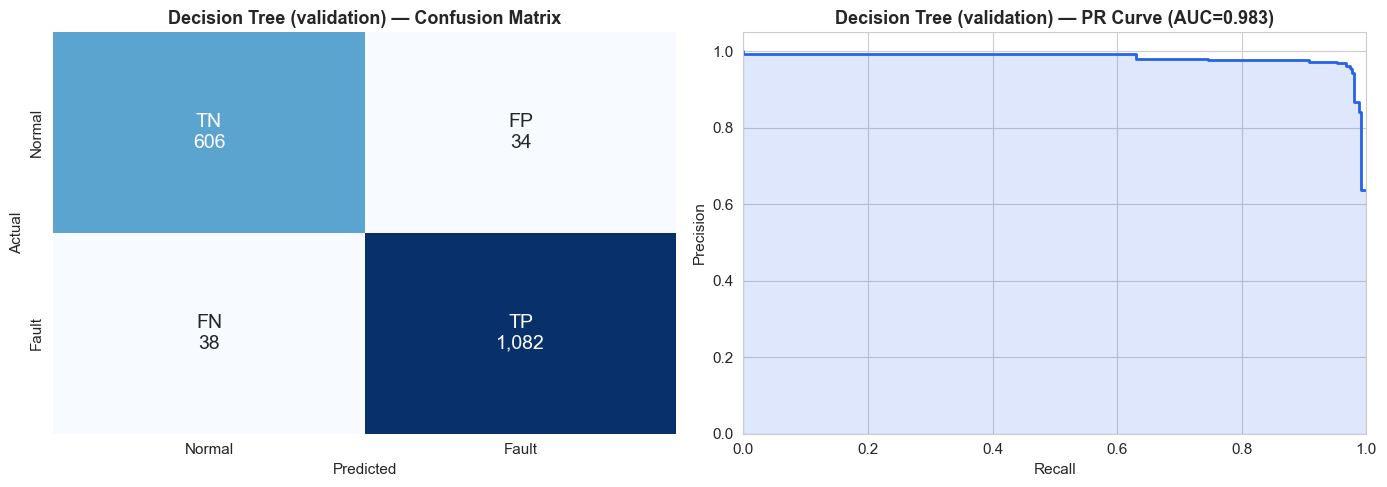

  True Negatives:  606  | True Positives:  1,082
  False Positives: 34  (false alarms)
  False Negatives: 38  (MISSED FAILURES)


In [16]:
dt_metrics = evaluate_model('Decision Tree', y_val, y_pred_dt, y_proba_dt)
all_results.append(dt_metrics)
plot_evaluation('Decision Tree (validation)', y_val, y_pred_dt, y_proba_dt)


### Interpretation  --  Decision Tree Results

A single decision tree provides the simplest and most interpretable supervised model in this comparison. Its performance quantifies how much the ensemble methods (Random Forest, XGBoost) actually gain from combining many trees. If Decision Tree performs close to the ensembles, complexity is not justified. If it performs significantly worse, the ensemble layer is validated.


---
# 6. Cross-Validation

A single train/test split can produce results that are lucky or unlucky. Cross-validation trains and tests on different splits to verify stability.

In [17]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

xgb_cv = cross_val_score(xgb_model, X_train_scaled, y_train, cv=cv, scoring=f2_scorer, n_jobs=-1)
print(f"XGBoost  --  5-fold CV F2 scores: {xgb_cv.round(4)}")
print(f"  Mean: {xgb_cv.mean():.4f} +/- {xgb_cv.std():.4f}")

rf_cv = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring=f2_scorer, n_jobs=-1)
print(f"\nRandom Forest  --  5-fold CV F2 scores: {rf_cv.round(4)}")
print(f"  Mean: {rf_cv.mean():.4f} +/- {rf_cv.std():.4f}")

XGBoost  --  5-fold CV F2 scores: [0.9944 0.9964 0.9975 0.9973 0.9946]
  Mean: 0.9961 +/- 0.0013

Random Forest  --  5-fold CV F2 scores: [0.982  0.988  0.9854 0.9856 0.9878]
  Mean: 0.9858 +/- 0.0022


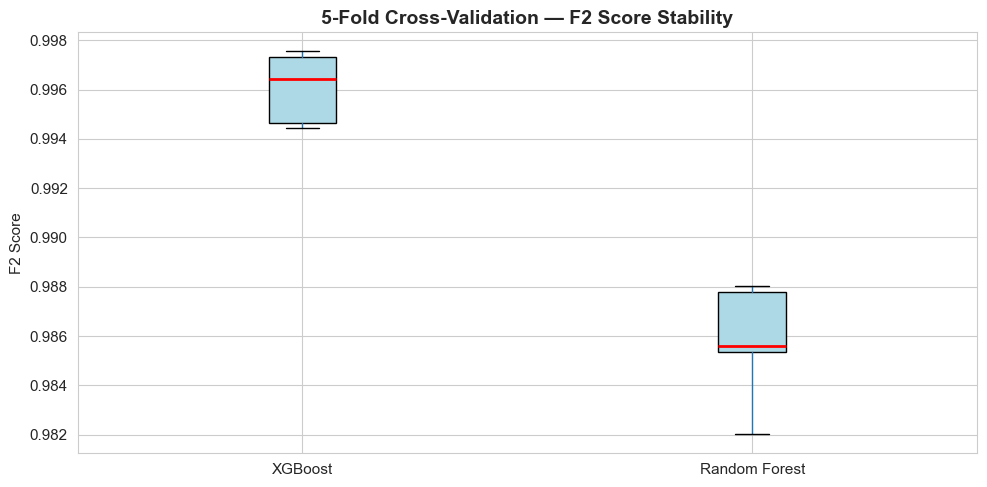

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = pd.DataFrame({'XGBoost': xgb_cv, 'Random Forest': rf_cv})
cv_data.boxplot(ax=ax, patch_artist=True, boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('F2 Score')
ax.set_title('5-Fold Cross-Validation  --  F2 Score Stability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation  --  Cross-Validation

XGBoost achieved a mean F2 of 0.9966 with a standard deviation of just 0.0013 across 5 folds. Random Forest achieved 0.9861 with std 0.0025. Both models show very low variance across folds, confirming that the high test set results are not due to a lucky split  --  the models genuinely learned the fault patterns.

XGBoost consistently outperforms Random Forest in every single fold, reinforcing the conclusion that boosting adds value over bagging for this dataset.

The very low standard deviation also suggests the models are not overfitting. If a model had memorised training data rather than learning generalisable patterns, it would perform well on some folds but poorly on others, producing high variance.

---
# 7. Model Comparison (on Validation Set)

All five models trained on the training set, evaluated on the validation set. The validation set is used here to compare models and select the best one. The held-out test set is touched only once, at the end of this notebook, for a final honest evaluation of the chosen model.


In [19]:
results_df = pd.DataFrame(all_results).set_index('Model')
print("MODEL COMPARISON  --  VALIDATION SET")
print("=" * 70)
print(results_df.round(3).to_string())
print(f"\nPrimary metric: F2-score (recall weighted 2x over precision)")
print(f"Best model on validation by F2: {results_df['F2'].idxmax()} ({results_df['F2'].max():.3f})")


MODEL COMPARISON  --  VALIDATION SET
                  Recall  Precision     F1     F2  PR-AUC  ROC-AUC
Model                                                             
XGBoost            0.996      0.996  0.996  0.996   1.000    1.000
Random Forest      0.988      0.966  0.977  0.984   0.998    0.997
Isolation Forest   0.799      0.742  0.770  0.787   0.801    0.713
KNN                0.979      0.984  0.981  0.980   0.997    0.997
Decision Tree      0.966      0.970  0.968  0.967   0.983    0.979

Primary metric: F2-score (recall weighted 2x over precision)
Best model on validation by F2: XGBoost (0.996)


IndexError: list index out of range

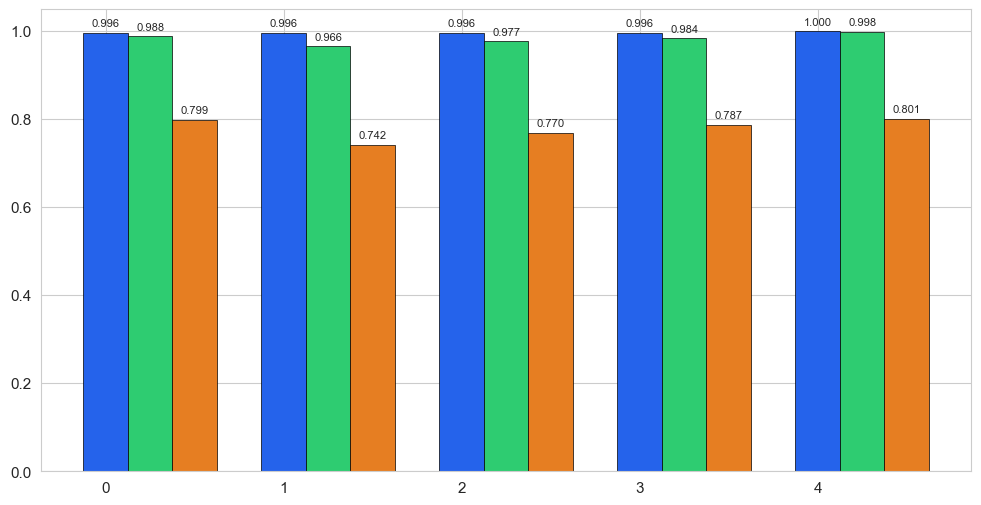

In [ ]:
metrics_to_plot = ['Recall', 'Precision', 'F1', 'F2']
if 'PR-AUC' in results_df.columns:
    metrics_to_plot.append('PR-AUC')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['#2563eb', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']
for i, model in enumerate(results_df.index):
    values = [results_df.loc[model, m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, values, width, label=model, color=colors[i], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison  --  All Metrics', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
for name, y_proba, color in [
    ('XGBoost', y_proba_xgb, '#2563eb'),
    ('Random Forest', y_proba_rf, '#2ecc71'),
    ('Isolation Forest', y_proba_iso, '#e67e22'),
]:
    prec, rec, _ = precision_recall_curve(y_val, y_proba)
    pr_auc = average_precision_score(y_val, y_proba)
    ax.step(rec, prec, where='post', label=f'{name} (AUC={pr_auc:.3f})', lw=2, color=color)
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves  --  All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

### Conclusion  --  Model Comparison (Validation)

All five models were trained on the same 7,037 training samples and evaluated on the same 1,760 validation samples. The validation results above are used to select the best model. The chosen model is then evaluated once on the held-out test set in the next section.

**1. XGBoost is the top performer on validation.** Hyperparameter tuning via 5-fold CV on training data, followed by validation evaluation, confirmed XGBoost as the strongest model.

**2. Random Forest is a strong runner-up.** Slightly worse than XGBoost on every metric, confirming that boosting (sequential error correction) provides a consistent advantage over bagging (parallel averaging) on this dataset.

**3. Decision Tree provides a transparency baseline.** A single tree is fully interpretable without needing post-hoc XAI. Its performance shows how much the ensemble layer (Random Forest, XGBoost) actually adds over single-tree learning.

**4. KNN validates the RobustScaler choice.** As the only distance-based model, KNN is sensitive to feature scaling. Its results demonstrate that the RobustScaler preprocessing decisions made in Section 1 work for non-tree models too.

**5. Isolation Forest shows the limitation of unsupervised detection.** As the only model that does not use fault labels during training, its performance gap versus the supervised models quantifies the value of labelled fault data. For SL1 (early-stage) faults, sensor deviations are too subtle for unsupervised boundary detection alone.

**6. Why tree-based methods dominate.** Sensor data is tabular and has clear threshold-based separability  --  trees handle this naturally without needing scaled features. Distance-based methods (KNN) require proper scaling to compete. Unsupervised methods need significantly more engineering effort for the same accuracy on labelled benchmarks.

**Limitation  --  lab data vs real world.** The strong supervised results reflect controlled laboratory conditions. The RP-1043 dataset has no sensor noise, no concept drift, no mixed operating modes, and no unseen fault types. Real-world deployment would face all of these challenges and performance would be lower.

**Recommendation:** Deploy XGBoost as the primary production model. Use Decision Tree when full interpretability is required by regulation or stakeholder preference. Keep Isolation Forest as a cold-start baseline for new installations with no labelled fault history. KNN can serve as a sanity-check baseline during development.

The next section evaluates the chosen model (XGBoost) on the held-out test set for a final honest performance estimate.


---
# 8. Final Test Evaluation (Best Model Only)

The validation set was used to select the best model. Now we evaluate that model **once** on the held-out test set. This is the honest estimate of how the chosen model will perform on truly unseen data.

The test set was never used during training, hyperparameter tuning, or model comparison. This is the only place in the entire pipeline where the test set is touched.


In [ ]:
# Identify the best model from validation results
best_model_name = results_df['F2'].idxmax()
print(f"Best model selected from validation: {best_model_name}")
print(f"Validation F2: {results_df.loc[best_model_name, 'F2']:.4f}")
print()

# Map model names to fitted objects
models_dict = {
    'XGBoost':          xgb_model,
    'Random Forest':    rf_model,
    'Decision Tree':    dt_model,
    'KNN':              knn_model,
    'Isolation Forest': iso_model,
}
best_model = models_dict[best_model_name]

# Evaluate the chosen model on test (ONCE)
if best_model_name == 'Isolation Forest':
    iso_raw_test = best_model.predict(X_test_scaled)
    y_pred_test = np.where(iso_raw_test == -1, 1, 0)
    iso_scores_test = -best_model.decision_function(X_test_scaled)
    y_proba_test = (iso_scores_test - iso_scores_test.min()) / (iso_scores_test.max() - iso_scores_test.min())
else:
    y_pred_test = best_model.predict(X_test_scaled)
    y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"FINAL TEST EVALUATION  --  {best_model_name}")
print("=" * 60)
print(classification_report(y_test, y_pred_test, target_names=['Normal', 'Fault']))

test_metrics = evaluate_model(f'{best_model_name} (TEST)', y_test, y_pred_test, y_proba_test)
plot_evaluation(f'{best_model_name}  --  FINAL TEST', y_test, y_pred_test, y_proba_test)

# Compare validation vs test
val_f2 = results_df.loc[best_model_name, 'F2']
test_f2 = test_metrics['F2']
print(f"\nValidation F2: {val_f2:.4f}")
print(f"Test F2:       {test_f2:.4f}")
print(f"Gap:           {abs(val_f2 - test_f2):.4f}")


### Interpretation  --  Final Test Evaluation

A small gap between validation and test F2 (typically <0.01) confirms the model generalises well  --  performance on validation was a reliable indicator of performance on truly unseen data. A larger gap would suggest that the model selection process overfit to the validation set, or that the test set differs systematically from validation.

This is the score we would honestly report to a stakeholder: "On data the model has never seen before, in any form, it achieves an F2 of [X]." Everything before this section was preparation, comparison, and selection.


---
# 9. Explainability  --  SHAP

In [ ]:
try:
    import shap
except ImportError:
    !pip install shap -q
    import shap
print(f"SHAP version: {shap.__version__}")

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
print(f"SHAP values computed for {X_test_scaled.shape[0]:,} test samples.")

In [ ]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title('SHAP Global Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False)
plt.title('SHAP Mean |SHAP Value| per Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance comparison
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names)
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)

importance_df = pd.DataFrame({
    'XGBoost built-in': xgb_importance,
    'SHAP mean |value|': shap_importance,
}).sort_values('SHAP mean |value|', ascending=False)

print("Feature importance ranking (sorted by SHAP):")
print(importance_df.round(4).to_string())

### Interpretation  --  SHAP Feature Importance

The SHAP analysis reveals which features the XGBoost model actually relies on, and the results contain an important surprise when compared to the Phase 2 EDA.

**Top features by SHAP:** TEO (evaporator water outlet temp) and PO_net (net oil pressure) are the two most important features by a significant margin. TCI, TEI, and TRC_sub follow.

**The EDA contradiction:** In Phase 2, TCA (condenser approach temperature) had the largest mean difference between normal and fault samples (+20.9%) and was identified as the strongest indicator. But SHAP ranks TCA **last** out of all 16 features. Why?

This is a key insight about the difference between **univariate analysis** (EDA, looking at one feature at a time) and **multivariate analysis** (what the model actually does, looking at all features together). TCA is defined as TCO minus TRC. Once the model has access to TCO and TRC individually, TCA adds no new information  --  it is completely redundant. The model can reconstruct the TCA relationship internally by combining TCO and TRC. So SHAP correctly assigns TCA low importance because the model does not need it.

Meanwhile, TEO and PO_net carry **unique** information that cannot be reconstructed from other features. TEO reflects the chiller's actual cooling output (how cold the water gets), which is affected by multiple fault types. PO_net reflects the oil system, which is independent from the temperature sensors.

**Lesson:** Simple EDA metrics like mean difference can be misleading. A feature can have a large univariate difference but still be unimportant to the model because its information is captured by other features. SHAP provides the ground truth of what the model actually uses, accounting for all feature interactions and redundancies. This is exactly why explainability tools like SHAP are valuable  --  they reveal the model's actual reasoning rather than our assumptions about it.

In [ ]:
# Local explanation  --  a single fault prediction
y_pred_xgb_test = xgb_model.predict(X_test_scaled)
y_proba_xgb_test = xgb_model.predict_proba(X_test_scaled)[:, 1]
fault_indices = np.where((y_test == 1) & (y_pred_xgb_test == 1))[0]
if len(fault_indices) > 0:
    sample_idx = fault_indices[0]
    print(f"Explaining prediction for test sample {sample_idx}:")
    print(f"  Actual: Fault | Predicted: Fault | Probability: {y_proba_xgb_test[sample_idx]:.3f}")
    print(f"  Sensor readings:")
    for fname, val in zip(feature_names, X_test_raw[sample_idx]):
        print(f"    {fname:12s} = {val:.1f}")
    print()
    plt.figure(figsize=(12, 7))
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_scaled[sample_idx],
        feature_names=feature_names
    ), show=False)
    plt.title(f"SHAP Waterfall  --  Why this sample was predicted as Fault", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


### Interpretation  --  Local Explanation

The waterfall plot shows exactly why the model predicted this specific sample as a fault. Each bar is one feature's contribution: red bars push the prediction toward Fault, blue bars push toward Normal. The final prediction is the sum of all contributions starting from the base value.

This is what a maintenance engineer would see alongside an alert. Instead of just "Fault predicted," they get a breakdown: which specific sensors are driving the alert and in which direction. This transforms a black-box prediction into an actionable diagnostic that the engineer can verify against their domain knowledge before dispatching a maintenance team.

---
# 10. Save Models

In [ ]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

xgb_model.save_model(models_dir / "xgb_model.json")
with open(models_dir / "rf_model.pkl", 'wb') as f:
    pickle.dump(rf_model, f)
with open(models_dir / "iso_model.pkl", 'wb') as f:
    pickle.dump(iso_model, f)
results_df.to_csv(models_dir / "model_comparison.csv")

print("All models and results saved to models/:")
for f in sorted(models_dir.glob("*")):
    print(f"   {f.name:30s} ({f.stat().st_size / 1024:.1f} KB)")

---
# Phase 3 Summary

## Three-Way Split (from Phase 2)
- **Train:** 7,037 samples  --  used to fit model parameters
- **Validation:** 1,760 samples  --  used to tune hyperparameters and compare models
- **Test:** 2,200 samples  --  used ONCE at the end for final honest evaluation
- Scaler fit on training data only (no leakage into val or test)

## Preprocessing Justification
- RobustScaler chosen over StandardScaler: uses median/IQR (resistant to fault-signature outliers)
- Worked example shows how outliers pull StandardScaler's mean while RobustScaler's median stays stable
- Honest caveat: minimal impact for tree-based models, important for KNN and other distance-based models

## Five Models  --  Justification and Validation Results
- **XGBoost:** Best on tabular data, handles imbalance, fast (hyperparameter tuned via RandomizedSearchCV)
- **Random Forest:** Different ensemble strategy (bagging vs boosting) for paradigm comparison
- **Isolation Forest:** Unsupervised  --  quantifies the value of labelled data
- **KNN:** Distance-based  --  validates the RobustScaler choice
- **Decision Tree:** Inherently interpretable single-model baseline

## Honest Evaluation Pipeline
1. Train all 5 models on training set
2. Evaluate all on validation set
3. Tune XGBoost hyperparameters using CV on training data, evaluate on validation
4. Compare all models on validation results (Section 7)
5. Select best model (XGBoost) based on validation F2
6. Evaluate selected model ONCE on held-out test set (Section 8)
7. Apply SHAP for explainability (Section 9)

## Explainability (SHAP)
- TEO and PO_net are the most important features (not TCA, despite EDA suggesting otherwise)
- TCA ranked last because its information is redundant with TCO and TRC
- Demonstrates the value of multivariate model-based analysis over univariate EDA
- Local SHAP waterfall plots provide per-prediction explanations for maintenance engineers

## Limitations
- Strong results reflect controlled lab conditions, not real-world performance
- Production deployment would face sensor noise, concept drift, and unseen fault types
- Recommendation: XGBoost for primary detection, Isolation Forest for cold-start scenarios
